Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully: (48536, 28)

Training Logistic Regression for: Motor_Symptoms

Results:
Accuracy : 0.3346774193548387
Precision: 0.33435668874348246
Recall   : 0.3346774193548387
F1-score : 0.33119381868102504
              precision    recall  f1-score   support

        Mild       0.33      0.25      0.29     11283
    Moderate       0.34      0.42      0.37     11383
      Severe       0.33      0.33      0.33     11310

    accuracy                           0.33     33976
   macro avg       0.33      0.33      0.33     33976
weighted avg       0.33      0.33      0.33     33976



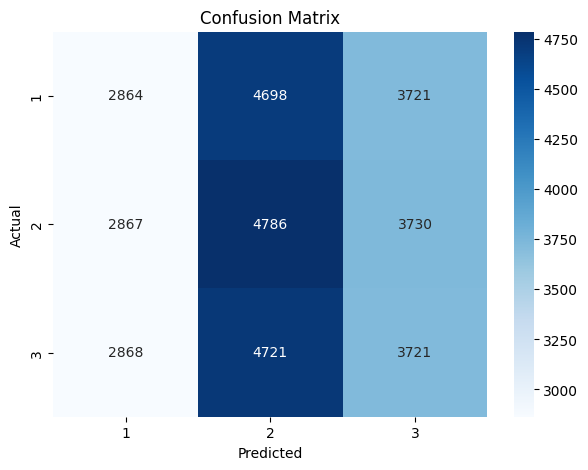

In [ ]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Mount Drive & Load Dataset

from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Huntington_Disease_Dataset_Preprocessed_Scaled.csv"
df = pd.read_csv(path)

print("Dataset loaded successfully:", df.shape)

# Prepare Target

target_col = 'Motor_Symptoms'
y = df[target_col].values

# Drop target and leakage columns
leakage_cols = [

    'Patient_ID',
    target_col   # drop target from features
]

X = df.drop(columns=leakage_cols, errors='ignore')

# Label encode categorical features
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.values

# Train/Test/Validation Split: 20% train, 10% val, 70% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.3333, random_state=42, stratify=y_trainval
)


# Train Logistic Regression

print("\n========================================")
print(f"Training Logistic Regression for: {target_col}")
print("========================================")

model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Prediction

y_pred = model.predict(X_test)

# Evaluation

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nResults:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print(classification_report(
    y_test,
    model.predict(X_test),
    target_names=['Mild', 'Moderate', 'Severe'],
    zero_division=0
))

# Confusion Matrix & Visualization

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully: (48536, 28)

Training Logistic Regression for: Disease_Stage

Results:
Accuracy : 0.2533258770897104
Precision: 0.251243948480615
Recall   : 0.2533258770897104
F1-score : 0.24270032502039945
                 precision    recall  f1-score   support

Pre-Symptomatic       0.26      0.24      0.24      8534
          Early       0.25      0.23      0.24      8423
         Middle       0.26      0.42      0.32      8602
           Late       0.24      0.13      0.17      8417

       accuracy                           0.25     33976
      macro avg       0.25      0.25      0.24     33976
   weighted avg       0.25      0.25      0.24     33976



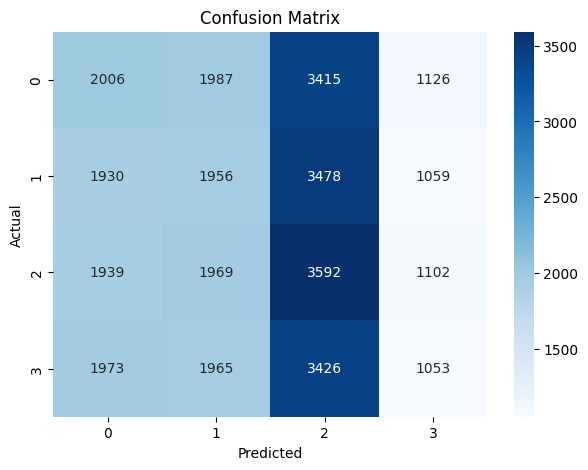

In [ ]:
# Import libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Mount Drive & Load Dataset

from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Huntington_Disease_Dataset_Preprocessed_Scaled.csv"
df = pd.read_csv(path)

print("Dataset loaded successfully:", df.shape)

# Prepare Target

target_col = 'Disease_Stage'
y = df[target_col].values

# Prepare Features

leakage_cols = [

    'Patient_ID',

    target_col   # drop target
]

X = df.drop(columns=leakage_cols, errors='ignore')

# Label encode categorical features
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.values

# Train/Test/Validation Split: 20% train, 10% val, 70% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.3333, random_state=42, stratify=y_trainval
)

# Train Logistic Regression

print("\n========================================")
print(f"Training Logistic Regression for: {target_col}")
print("========================================")

model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Prediction

y_pred = model.predict(X_test)

# Evaluation

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nResults:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print(classification_report(
    y_test,
    model.predict(X_test),
    target_names=['Pre-Symptomatic', 'Early', 'Middle', 'Late'],
    zero_division=0
))
# Confusion Matrix & Visualization

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully: (48536, 28)

Training Logistic Regression for: Category

Results:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:

                       precision    recall  f1-score   support

        Primary Cause       1.00      1.00      1.00      8560
Trans-acting Modifier       1.00      1.00      1.00     16996
  Cis-acting Modifier       1.00      1.00      1.00      8420

             accuracy                           1.00     33976
            macro avg       1.00      1.00      1.00     33976
         weighted avg       1.00      1.00      1.00     33976



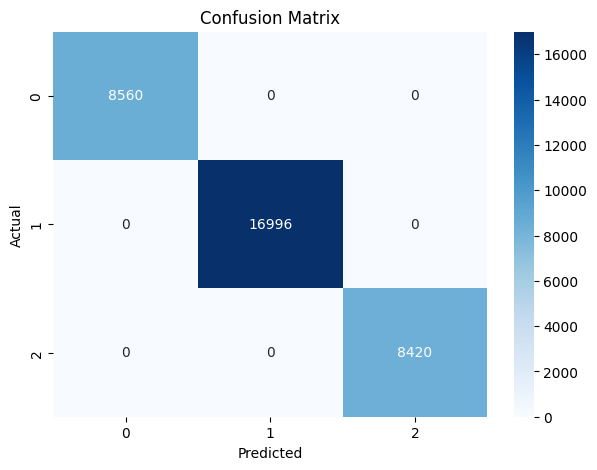

In [ ]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Mount Drive & Load Dataset

from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Huntington_Disease_Dataset_Preprocessed_Scaled.csv"
df = pd.read_csv(path)

print("Dataset loaded successfully:", df.shape)


#Convert one-hot target → single label

def onehot_to_label(row):
    if row['Category_Primary Cause'] == 1:
        return 0   # Primary Cause
    elif row['Category_Trans-acting Modifier'] == 1:
        return 1   # Trans-acting Modifier
    else:
        return 2   # Cis-acting Modifier

df['Category'] = df.apply(onehot_to_label, axis=1)

y = df['Category'].values

# Prepare Features
leakage_cols = [

    'Patient_ID',                  # ID column
    'Random_Protein_Sequence',     # synthetic / deterministic
    'Random_Gene_Sequence',        # synthetic / deterministic

]

X = df.drop(columns=leakage_cols, errors='ignore')

# Label Encode categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.values

# Train/Test/Validation Split: 20% train, 10% val, 70% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.3333, random_state=42, stratify=y_trainval
)


#  Train Logistic Regression

print("\n========================================")
print("Training Logistic Regression for: Category")
print("========================================")

model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Prediction

y_pred = model.predict(X_test)

# Evaluation

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("\nResults:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=[
        'Primary Cause',
        'Trans-acting Modifier',
        'Cis-acting Modifier'
    ]
))
# Confusion Matrix & Visualization

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Columns to check
category_cols = ['Category', 'Category_Primary Cause', 'Category_Trans-acting Modifier']

print("=== Category Columns Summary ===\n")

for col in category_cols:
    print(f"Column: {col}")

    # Unique values
    unique_vals = df[col].unique()
    print(f"  Unique values       : {unique_vals}")

    # Value counts
    counts = df[col].value_counts()
    print(f"  Value counts:\n{counts}")

    # Check for missing values
    missing = df[col].isnull().sum()
    print(f"  Missing values      : {missing}")

    # Optional: check for rare categories (less than 1% of data)
    rare_threshold = 0.01 * len(df)
    rare_vals = counts[counts < rare_threshold]
    if not rare_vals.empty:
        print(f"  Rare categories (<1% of data):\n{rare_vals}")
    else:
        print(f"  No rare categories (<1%)")

    print("-" * 50)

=== Category Columns Summary ===

Column: Category
  Unique values       : [0 1 2]
  Value counts:
Category
1    24279
0    12229
2    12028
Name: count, dtype: int64
  Missing values      : 0
  No rare categories (<1%)
--------------------------------------------------
Column: Category_Primary Cause
  Unique values       : [1 0]
  Value counts:
Category_Primary Cause
0    36307
1    12229
Name: count, dtype: int64
  Missing values      : 0
  No rare categories (<1%)
--------------------------------------------------
Column: Category_Trans-acting Modifier
  Unique values       : [0 1]
  Value counts:
Category_Trans-acting Modifier
1    24279
0    24257
Name: count, dtype: int64
  Missing values      : 0
  No rare categories (<1%)
--------------------------------------------------


In [ ]:
# Columns to check
category_cols = ['Category', 'Category_Primary Cause', 'Category_Trans-acting Modifier']

# Expected values
expected_values = {
    'Category': [0, 1, 2],
    'Category_Primary Cause': [0, 1],
    'Category_Trans-acting Modifier': [0, 1]
}

print("=== Category Columns Outlier Check ===\n")

for col in category_cols:
    unexpected = df[~df[col].isin(expected_values[col])]

    if unexpected.empty:
        print(f"{col}: No outliers ✅")
    else:
        print(f"{col}: Outliers found ❌")
        print(unexpected[col].unique())

=== Category Columns Outlier Check ===

Category: No outliers ✅
Category_Primary Cause: No outliers ✅
Category_Trans-acting Modifier: No outliers ✅


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully: (48536, 28)

Training Logistic Regression for: Motor_Symptoms
Epoch 20/200 - Train Accuracy: 0.3366
Epoch 40/200 - Train Accuracy: 0.3367
Epoch 60/200 - Train Accuracy: 0.3371
Epoch 80/200 - Train Accuracy: 0.3369
Epoch 100/200 - Train Accuracy: 0.3367
Epoch 120/200 - Train Accuracy: 0.3370
Epoch 140/200 - Train Accuracy: 0.3367
Epoch 160/200 - Train Accuracy: 0.3366
Epoch 180/200 - Train Accuracy: 0.3373
Epoch 200/200 - Train Accuracy: 0.3373

Results:
Accuracy : 0.3293501295031787
Precision: 0.32998891608713954
Recall   : 0.3293501295031787
F1-score : 0.309750840927494

Classification Report:

              precision    recall  f1-score   support

        Mild       0.33      0.42      0.37     11283
    Moderate       0.33      0.13      0.18     11383
      Severe       0.33      0.44      0.38     11310

    accuracy         

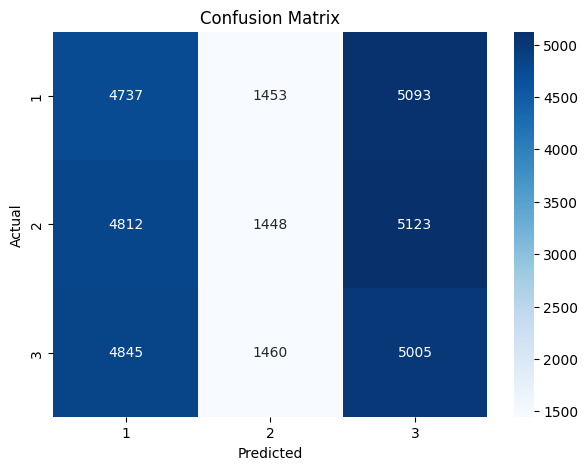

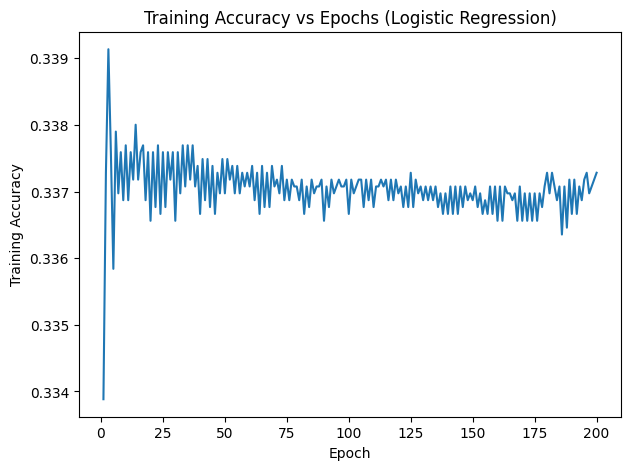

In [ ]:
# ===================== IMPORT LIBRARIES =====================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# ===================== MOUNT DRIVE & LOAD DATASET =====================
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Huntington_Disease_Dataset_Preprocessed_Scaled.csv"
df = pd.read_csv(path)

print("Dataset loaded successfully:", df.shape)

# ===================== PREPARE TARGET =====================
target_col = 'Motor_Symptoms'
y = df[target_col].values

# ===================== PREPARE FEATURES =====================
leakage_cols = [
    'Patient_ID',
    target_col
]

X = df.drop(columns=leakage_cols, errors='ignore')

# Label encode categorical features
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.values

# ===================== TRAIN / VAL / TEST SPLIT =====================
# 20% train, 10% val, 70% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.3333,
    random_state=42,
    stratify=y_trainval
)

# ===================== LOGISTIC REGRESSION WITH 200 EPOCHS =====================
print("\n========================================")
print(f"Training Logistic Regression for: {target_col}")
print("========================================")

model = LogisticRegression(
    solver='lbfgs',
    max_iter=1,        # one iteration per epoch
    warm_start=True,   # retain weights across epochs
    n_jobs=-1
)

EPOCHS = 200
train_acc_history = []

for epoch in range(EPOCHS):
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    train_acc_history.append(train_acc)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Accuracy: {train_acc:.4f}")

# ===================== TEST PREDICTION =====================
y_pred = model.predict(X_test)

# ===================== EVALUATION =====================
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nResults:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Mild', 'Moderate', 'Severe'],
    zero_division=0
))

# ===================== CONFUSION MATRIX =====================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ===================== EPOCH VS TRAIN ACCURACY =====================
plt.figure(figsize=(7,5))
plt.plot(range(1, EPOCHS + 1), train_acc_history)
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Epochs (Logistic Regression)")
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully: (48536, 28)

Training Logistic Regression for: Disease_Stage
Epoch 20/200 - Train Accuracy: 0.2573
Epoch 40/200 - Train Accuracy: 0.2575
Epoch 60/200 - Train Accuracy: 0.2575
Epoch 80/200 - Train Accuracy: 0.2575
Epoch 100/200 - Train Accuracy: 0.2575
Epoch 120/200 - Train Accuracy: 0.2575
Epoch 140/200 - Train Accuracy: 0.2575
Epoch 160/200 - Train Accuracy: 0.2574
Epoch 180/200 - Train Accuracy: 0.2573
Epoch 200/200 - Train Accuracy: 0.2572

Results:
Accuracy : 0.25373793265834704
Precision: 0.1283912944168305
Recall   : 0.25373793265834704
F1-score : 0.16680202043132214

Classification Report:

                 precision    recall  f1-score   support

Pre-Symptomatic       0.26      0.35      0.30      8534
          Early       0.00      0.00      0.00      8423
         Middle       0.25      0.65      0.36      8602
        

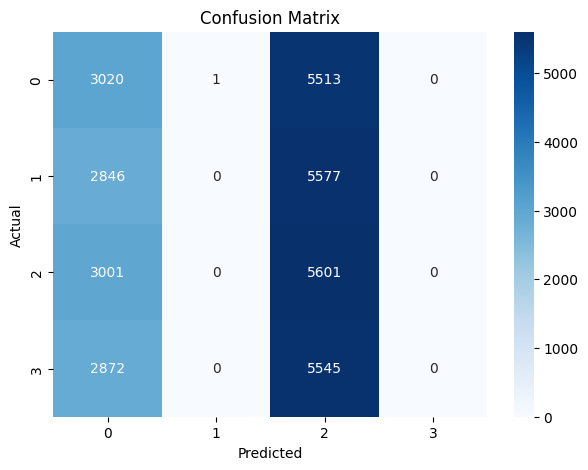

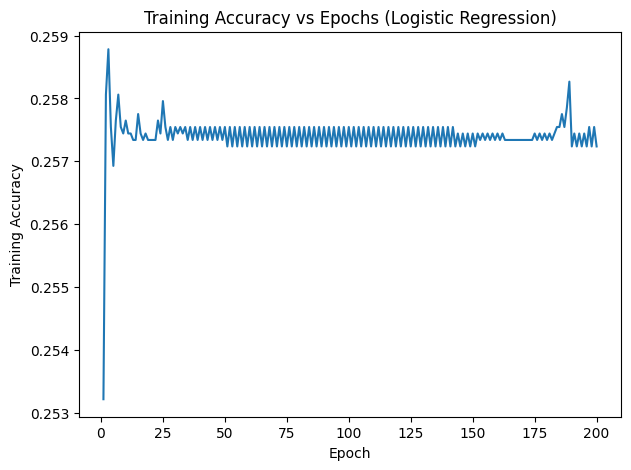

In [ ]:
# ===================== IMPORT LIBRARIES =====================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# ===================== MOUNT DRIVE & LOAD DATASET =====================
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Huntington_Disease_Dataset_Preprocessed_Scaled.csv"
df = pd.read_csv(path)

print("Dataset loaded successfully:", df.shape)

# ===================== PREPARE TARGET =====================
target_col = 'Disease_Stage'
y = df[target_col].values

# ===================== PREPARE FEATURES =====================
leakage_cols = [
    'Patient_ID',
    target_col
]

X = df.drop(columns=leakage_cols, errors='ignore')

# Label encode categorical features
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.values

# ===================== TRAIN / VAL / TEST SPLIT =====================
# 20% train, 10% val, 70% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.3333,
    random_state=42,
    stratify=y_trainval
)

# ===================== LOGISTIC REGRESSION WITH 200 EPOCHS =====================
print("\n========================================")
print(f"Training Logistic Regression for: {target_col}")
print("========================================")

model = LogisticRegression(
    solver='lbfgs',
    max_iter=1,        # one iteration per epoch
    warm_start=True,   # retain weights
    n_jobs=-1
)

EPOCHS = 200
train_acc_history = []

for epoch in range(EPOCHS):
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    train_acc_history.append(train_acc)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Accuracy: {train_acc:.4f}")

# ===================== TEST PREDICTION =====================
y_pred = model.predict(X_test)

# ===================== EVALUATION =====================
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nResults:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Pre-Symptomatic', 'Early', 'Middle', 'Late'],
    zero_division=0
))

# ===================== CONFUSION MATRIX =====================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ===================== EPOCH VS TRAIN ACCURACY =====================
plt.figure(figsize=(7,5))
plt.plot(range(1, EPOCHS + 1), train_acc_history)
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Epochs (Logistic Regression)")
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully: (48536, 28)

Training Logistic Regression for: Category
Epoch 20/200 - Train Accuracy: 0.5003
Epoch 40/200 - Train Accuracy: 0.5003
Epoch 60/200 - Train Accuracy: 0.7248
Epoch 80/200 - Train Accuracy: 0.7458
Epoch 100/200 - Train Accuracy: 0.7610
Epoch 120/200 - Train Accuracy: 0.7658
Epoch 140/200 - Train Accuracy: 0.7915
Epoch 160/200 - Train Accuracy: 0.9946
Epoch 180/200 - Train Accuracy: 0.9962
Epoch 200/200 - Train Accuracy: 1.0000

Results:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:

                       precision    recall  f1-score   support

        Primary Cause       1.00      1.00      1.00      8560
Trans-acting Modifier       1.00      1.00      1.00     16996
  Cis-acting Modifier       1.00      1.00      1.00      8420

             accuracy                           1.0

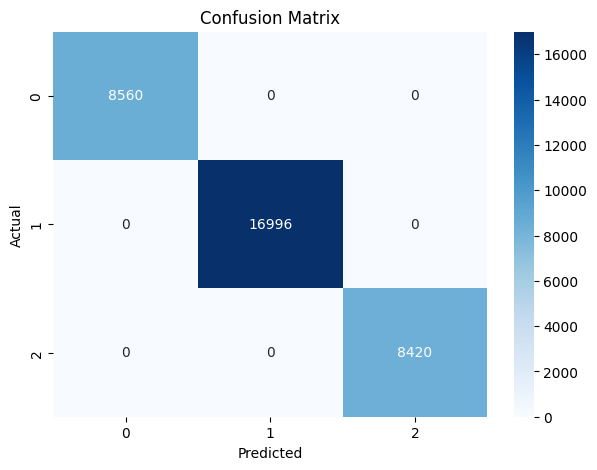

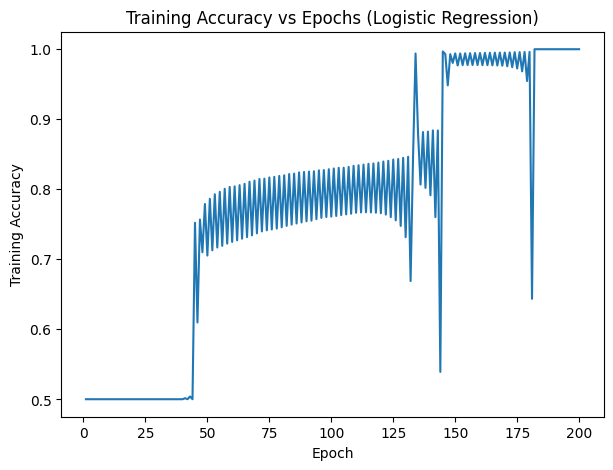

In [ ]:
# ===================== IMPORT LIBRARIES =====================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# ===================== MOUNT DRIVE & LOAD DATASET =====================
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Huntington_Disease_Dataset_Preprocessed_Scaled.csv"
df = pd.read_csv(path)

print("Dataset loaded successfully:", df.shape)

# ===================== CONVERT ONE-HOT TARGET → SINGLE LABEL =====================
def onehot_to_label(row):
    if row['Category_Primary Cause'] == 1:
        return 0   # Primary Cause
    elif row['Category_Trans-acting Modifier'] == 1:
        return 1   # Trans-acting Modifier
    else:
        return 2   # Cis-acting Modifier

df['Category'] = df.apply(onehot_to_label, axis=1)
y = df['Category'].values

# ===================== PREPARE FEATURES =====================
leakage_cols = [
    'Patient_ID',
    'Random_Protein_Sequence',
    'Random_Gene_Sequence'
]

X = df.drop(columns=leakage_cols, errors='ignore')

# Label Encode categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.values

# ===================== TRAIN / VAL / TEST SPLIT =====================
# 20% train, 10% val, 70% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.3333,
    random_state=42, stratify=y_trainval
)

# ===================== LOGISTIC REGRESSION WITH EPOCHS =====================
print("\n========================================")
print("Training Logistic Regression for: Category")
print("========================================")

model = LogisticRegression(
    solver='lbfgs',
    max_iter=1,        # 1 iteration per epoch
    warm_start=True,   # retain weights between epochs
    n_jobs=-1
)

EPOCHS = 200
train_acc_history = []

for epoch in range(EPOCHS):
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    train_acc_history.append(train_acc)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Accuracy: {train_acc:.4f}")

# ===================== TEST PREDICTION =====================
y_pred = model.predict(X_test)

# ===================== EVALUATION =====================
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("\nResults:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=[
        'Primary Cause',
        'Trans-acting Modifier',
        'Cis-acting Modifier'
    ]
))

# ===================== CONFUSION MATRIX =====================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ===================== EPOCH VS TRAIN ACCURACY PLOT =====================
plt.figure(figsize=(7,5))
plt.plot(range(1, EPOCHS+1), train_acc_history)
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Epochs (Logistic Regression)")
plt.show()
